# Experiment 2
## 10x10 grid of procedural changes to setpoint and drive voltage




[[<tools.IBWData object at 0x149d192b0>, <tools.IBWData object at 0x149d1c7d0>, <tools.IBWData object at 0x149d1c910>, <tools.IBWData object at 0x149bd5f30>, <tools.IBWData object at 0x149bd62c0>, <tools.IBWData object at 0x12b79b410>, <tools.IBWData object at 0x149d44160>, <tools.IBWData object at 0x149d44270>, <tools.IBWData object at 0x149cc5650>, <tools.IBWData object at 0x149cc6d50>], [<tools.IBWData object at 0x149c1f3e0>, <tools.IBWData object at 0x149c1f7a0>, <tools.IBWData object at 0x149cd9c50>, <tools.IBWData object at 0x149cd9e10>, <tools.IBWData object at 0x149ce7ba0>, <tools.IBWData object at 0x149b77e90>, <tools.IBWData object at 0x149b77110>, <tools.IBWData object at 0x148ce9b20>, <tools.IBWData object at 0x149bfb8b0>, <tools.IBWData object at 0x12ca7d3b0>], [<tools.IBWData object at 0x149d59590>, <tools.IBWData object at 0x149cbfd10>, <tools.IBWData object at 0x149ce8a50>, <tools.IBWData object at 0x149ce8ad0>, <tools.IBWData object at 0x149ce88d0>, <tools.IBWData obje

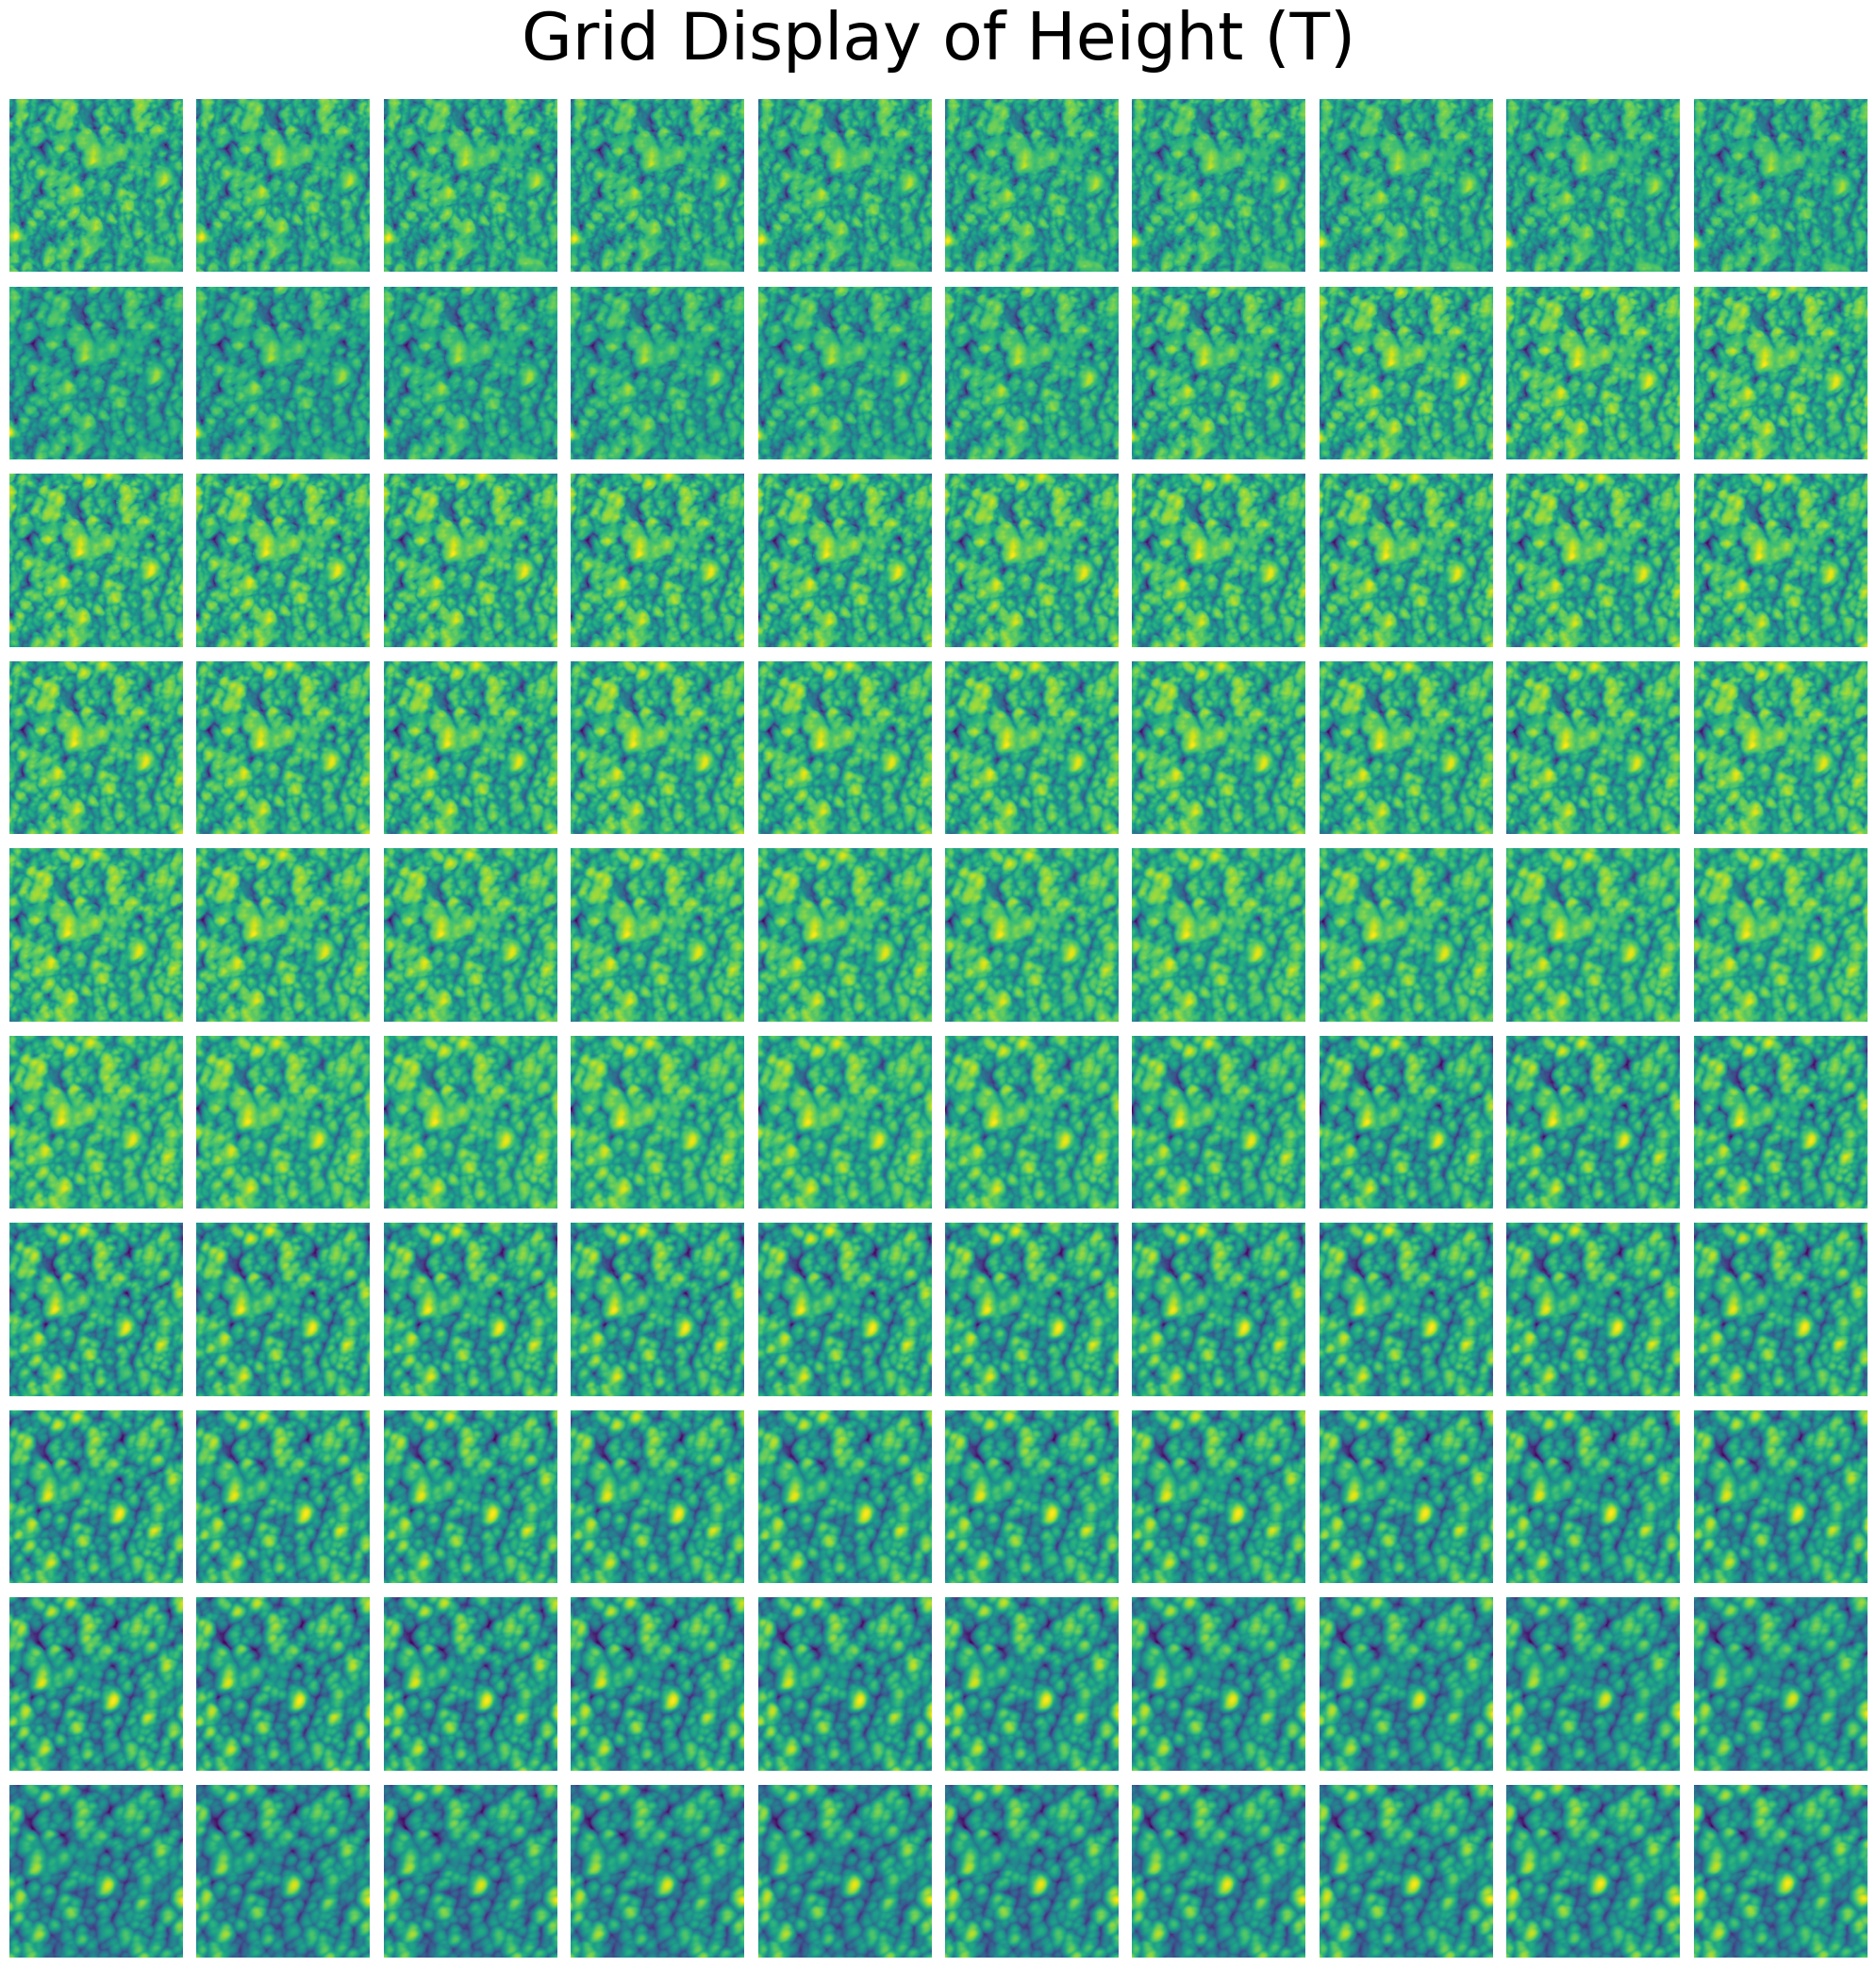

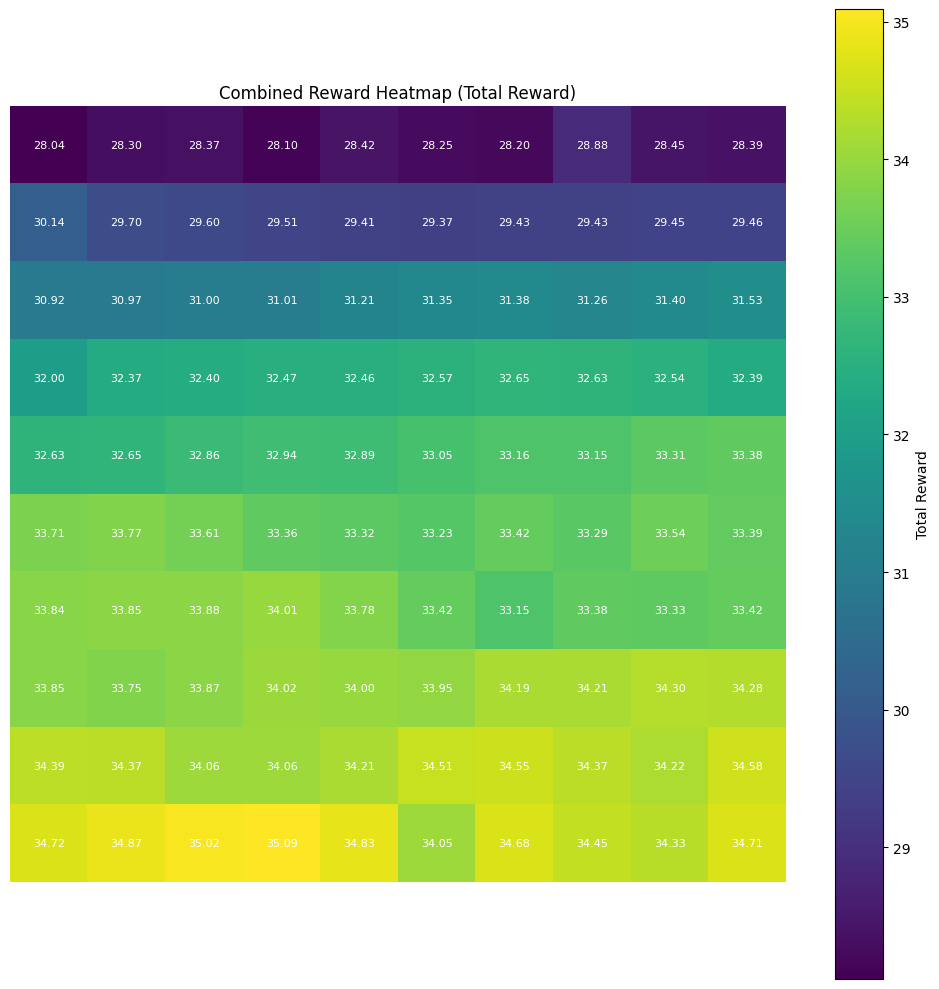

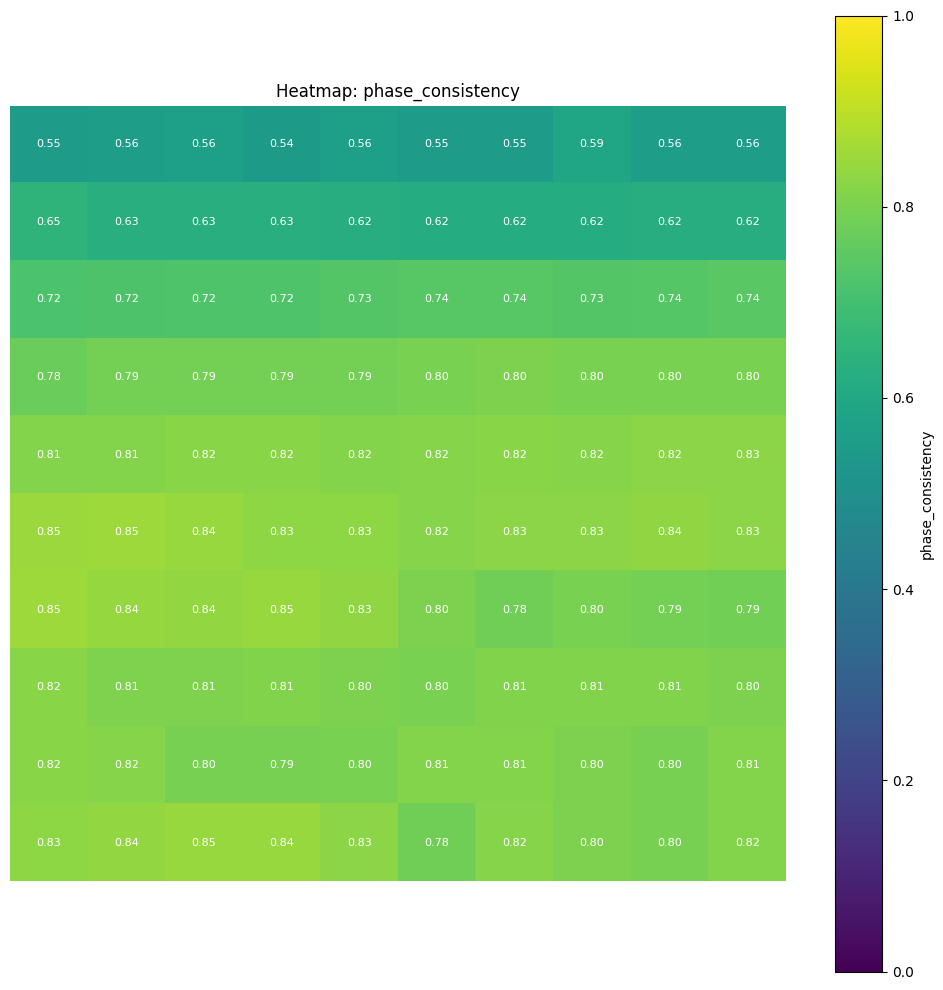

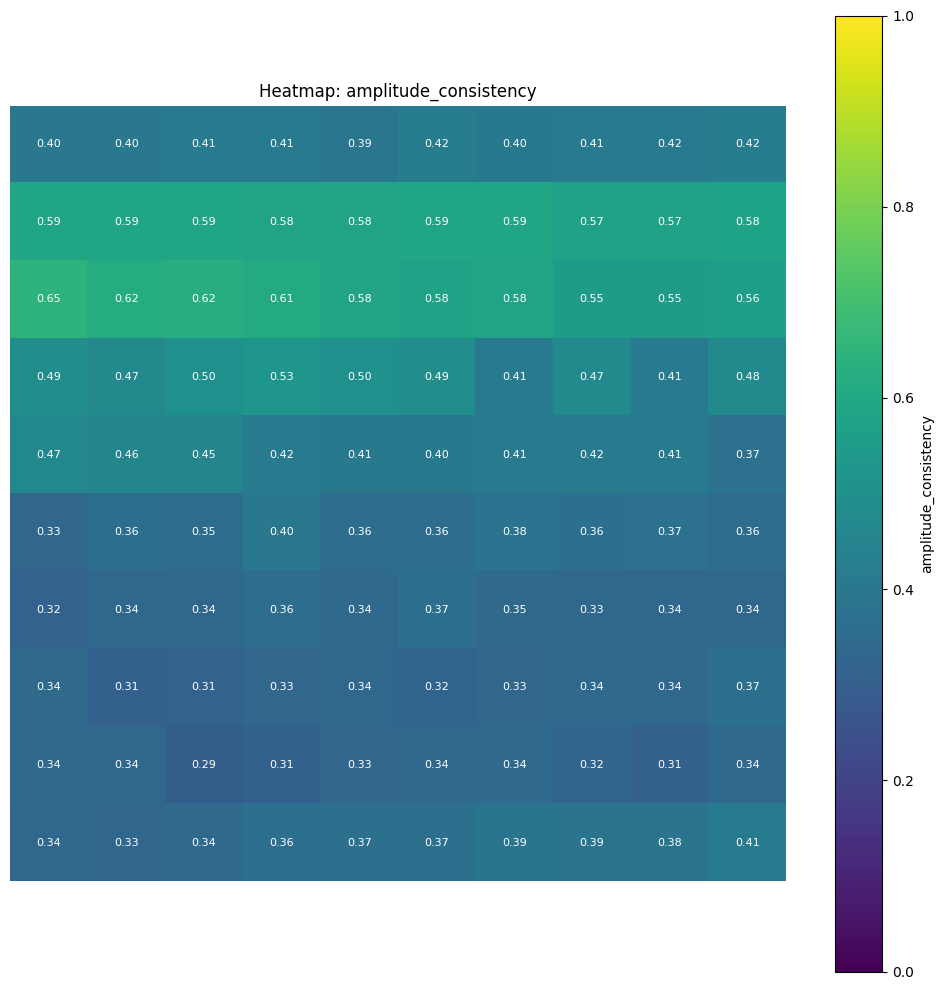

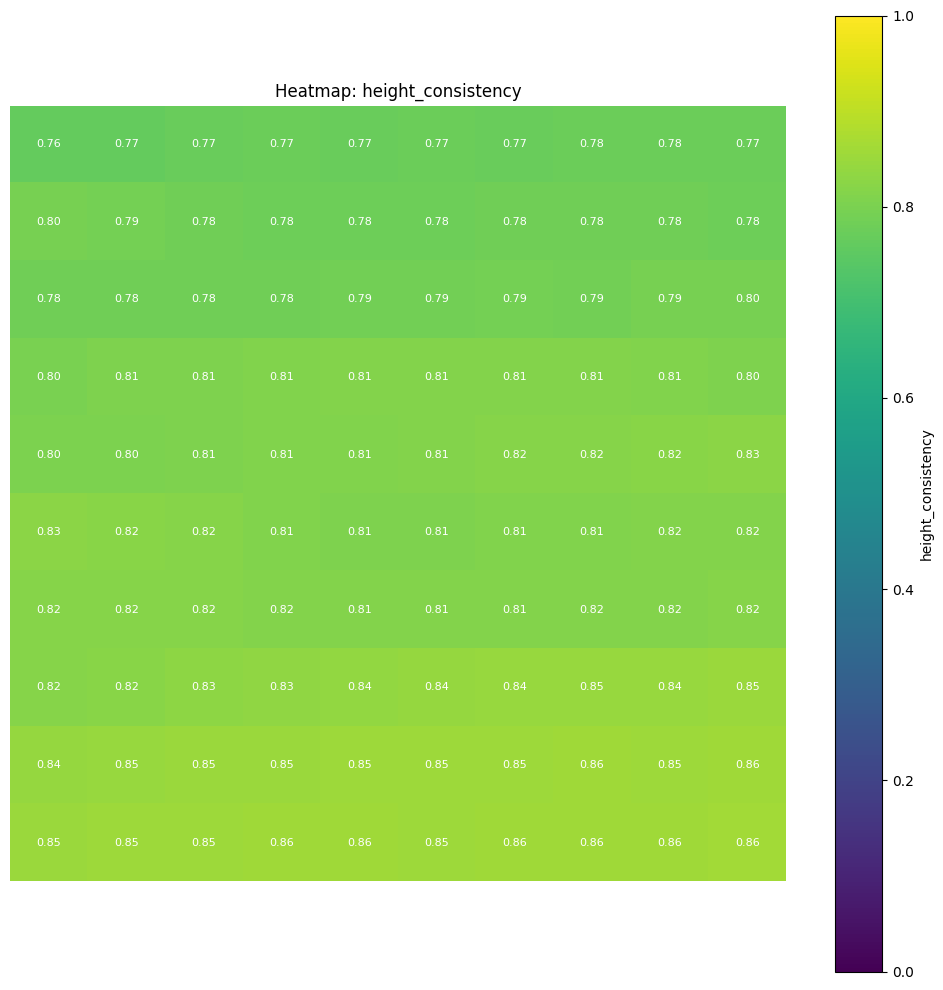

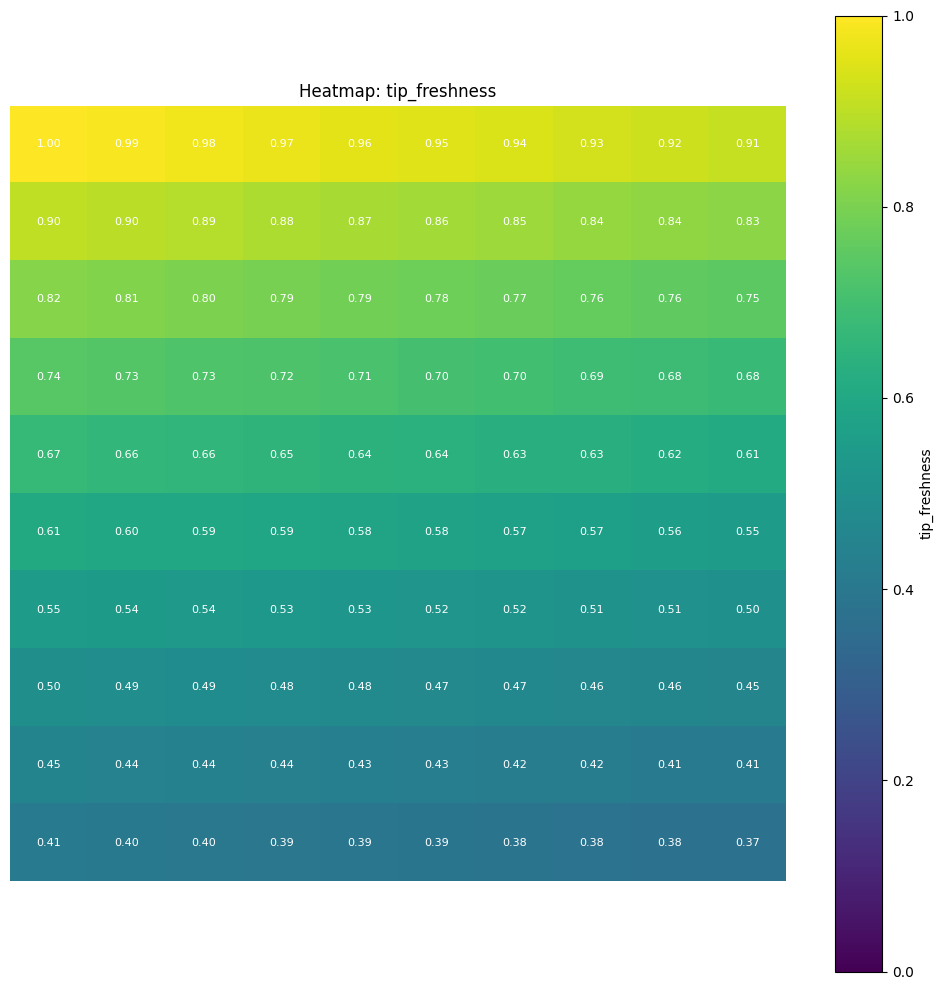

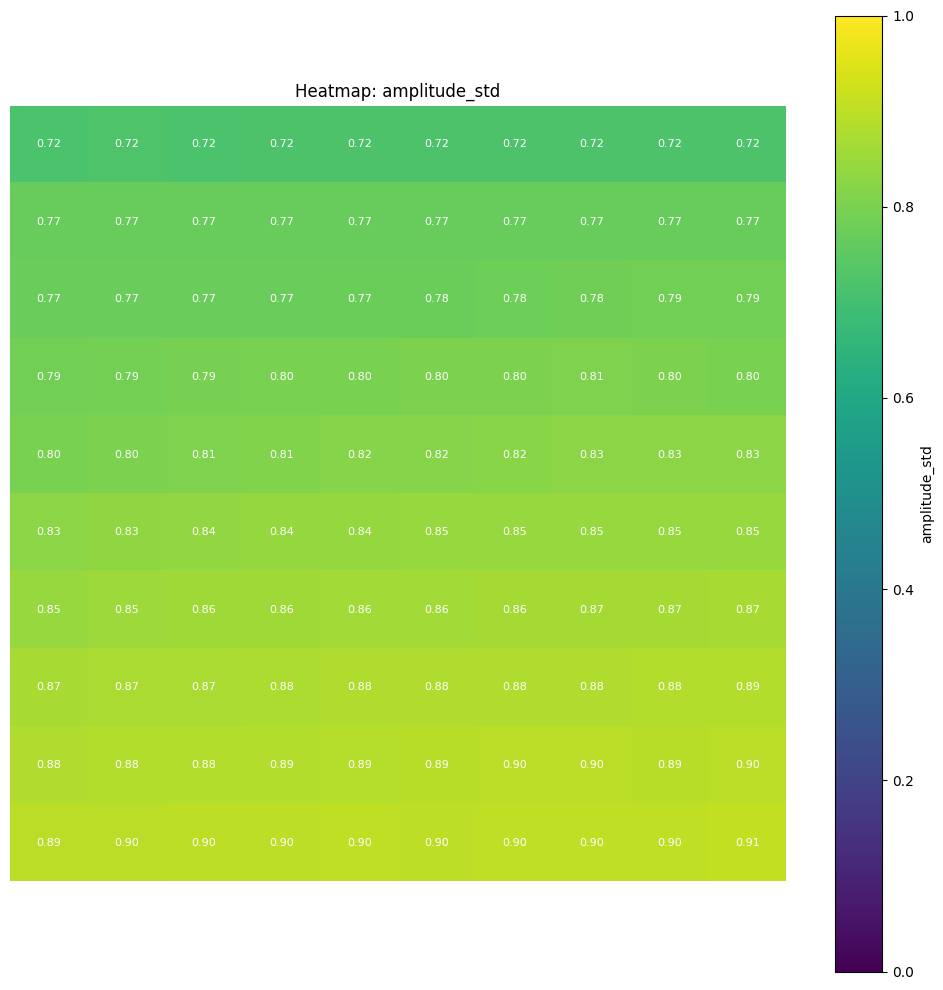

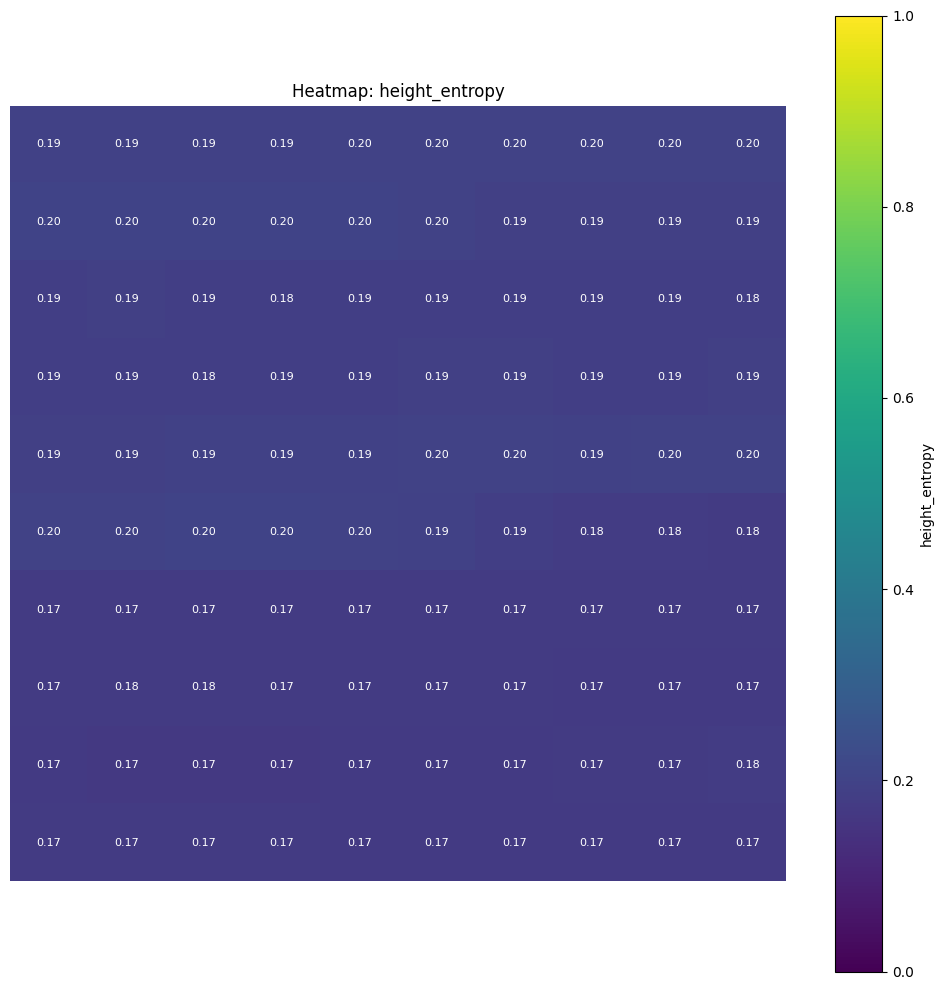

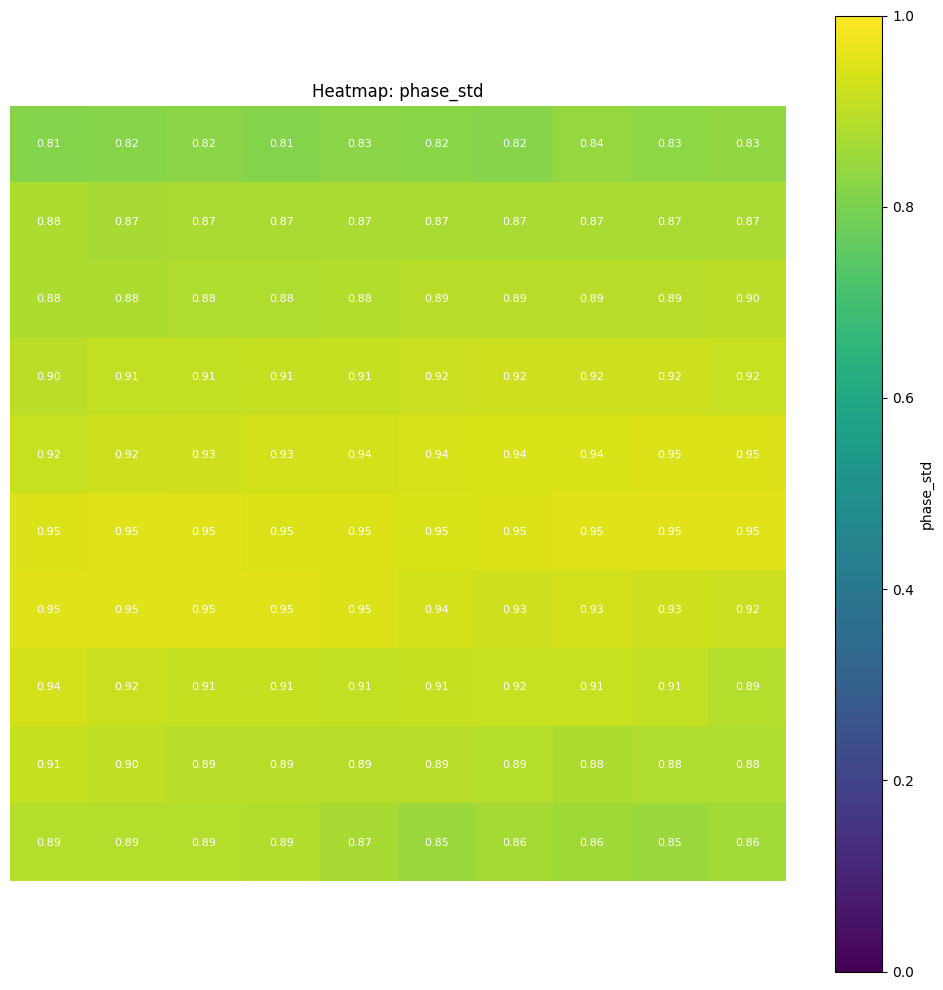

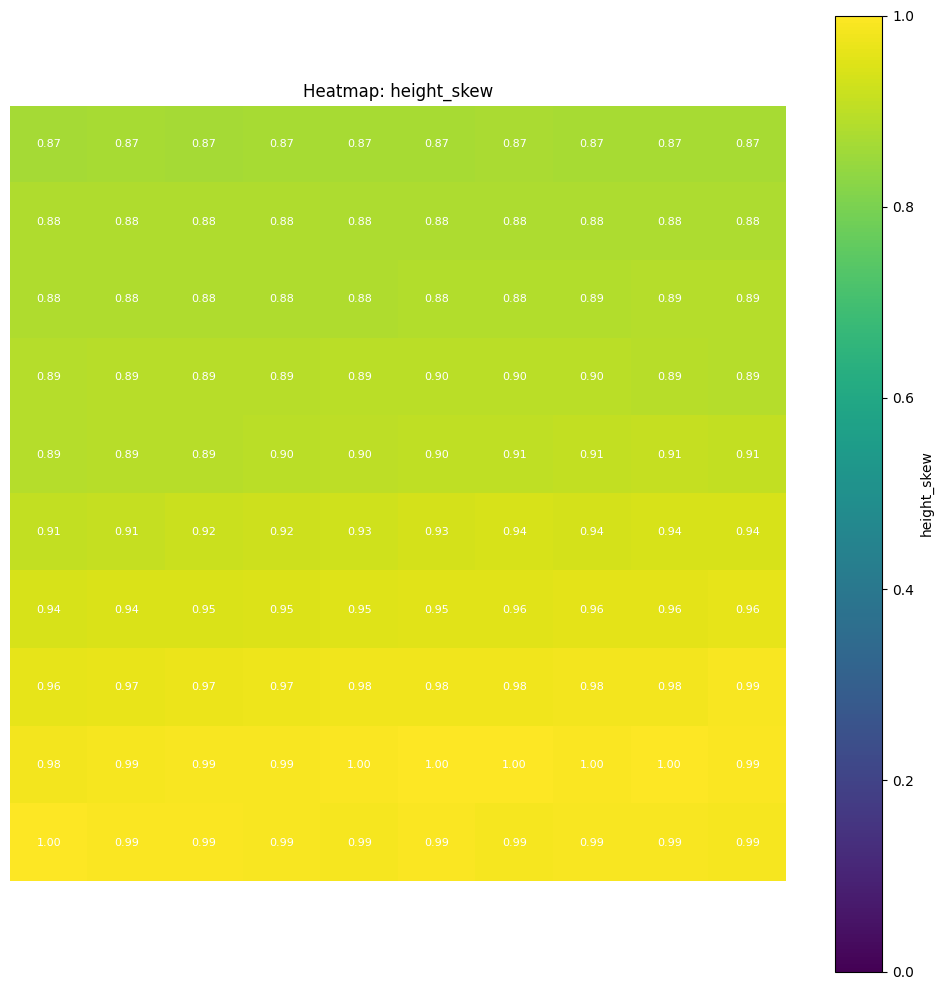

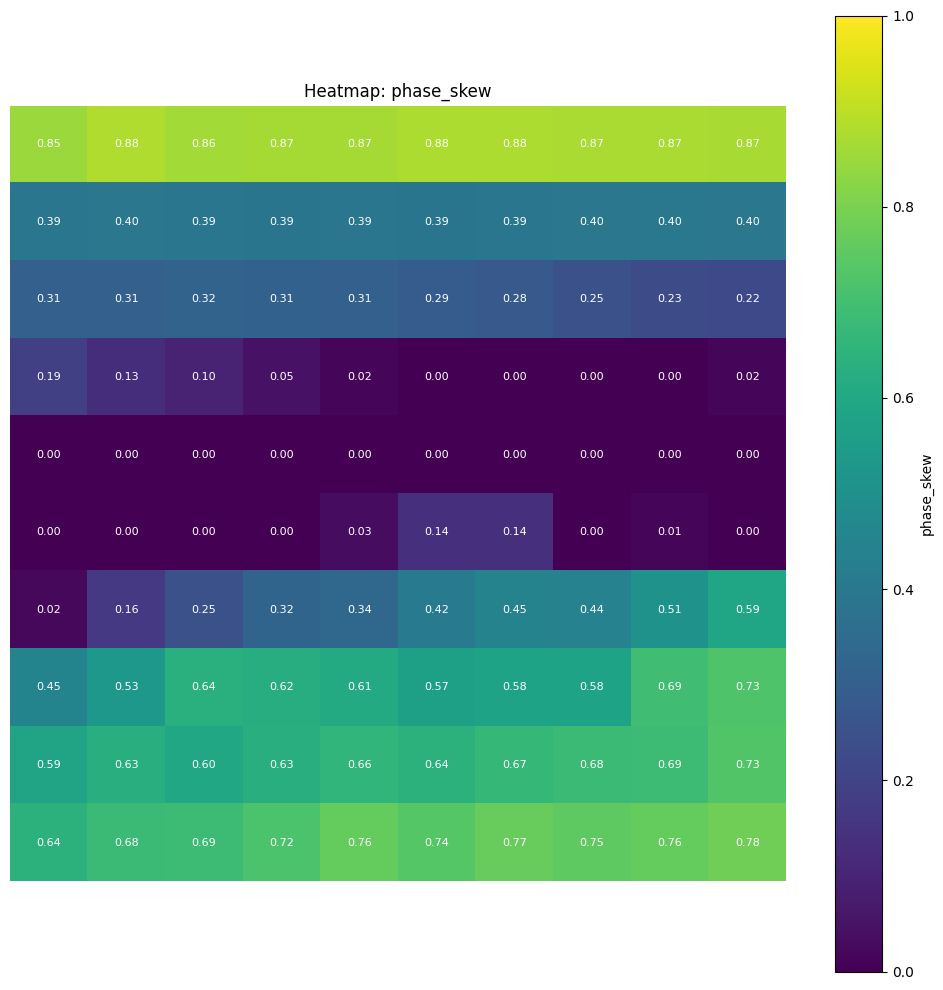

[[{'phase_consistency': 0.551861006459135, 'height_consistency': 0.7640746192180412, 'tip_freshness': 1.0, 'amplitude_std': 0.715498244512446, 'height_entropy': 0.19389261330162044, 'phase_std': 0.8144647181034088, 'height_skew': 0.8667120814323426, 'amplitude_consistency': 0.40032360589208277, 'phase_skew': 0.8484443783760071}, {'phase_consistency': 0.5624264883952874, 'height_consistency': 0.7652714419711808, 'tip_freshness': 0.9900498337491681, 'amplitude_std': 0.7248948613304265, 'height_entropy': 0.1925333546128296, 'phase_std': 0.816868782043457, 'height_skew': 0.8699318170547485, 'amplitude_consistency': 0.3999668916445846, 'phase_skew': 0.8816828250885009}, {'phase_consistency': 0.5647017954263838, 'height_consistency': 0.7704185943172911, 'tip_freshness': 0.9801986733067553, 'amplitude_std': 0.7168249610268731, 'height_entropy': 0.194461930166813, 'phase_std': 0.8245622962713242, 'height_skew': 0.8668486714363098, 'amplitude_consistency': 0.40994939790278484, 'phase_skew': 0.8

In [1]:
from tools import load_ibw, display_ibw, extract_scan_index_from_filename, compute_reward_with_top_features
import matplotlib.pyplot as plt
import numpy as np
import os

# Function to show the entire grid (may have to localize since it's 10x10)

def get_ibw_grid(ibw_parent_folder, grid_size=10, channel_name='Height (T)'):
    # Take the parent folder provided and create an array of .ibw objects
    # from the tools in tools.py

    # Configure the grid as a 2D array
    grid = [[None for _ in range(grid_size)] for _ in range(grid_size)]

    # Assuming that the data is unordered or not named properly, let's
    # grab the scan index from each file and store it in a dict
    scan_index_dict = {}
    for filename in os.listdir(ibw_parent_folder):
        if filename.endswith('.ibw'):
            scan_index = extract_scan_index_from_filename(filename)
            scan_index_dict[filename] = scan_index

    # Create a reverse lookup: scan_index -> filename
    index_to_filename = {v: k for k, v in scan_index_dict.items()}

    # Fill the grid based on scan index
    for scan_index in range(grid_size * grid_size):
        filename = index_to_filename.get(scan_index)
        if filename:
            row = scan_index // grid_size
            col = scan_index % grid_size
            filepath = os.path.join(ibw_parent_folder, filename)
            grid[row][col] = load_ibw(filepath)

    return grid

def display_ibw_grid_images(grid, channel_name='Height (T)', titles=None, cmaps=None, save=None, **kwargs):
    """
    Display a 2D grid of ibw images for a specified channel.
    """
    n_rows = len(grid)
    n_cols = len(grid[0]) if n_rows > 0 else 0

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*2, n_rows*2))
    for i in range(n_rows):
        for j in range(n_cols):
            ax = axes[i, j] if n_rows > 1 and n_cols > 1 else axes[max(i, j)]
            ibw_obj = grid[i][j]
            ax.axis('off')
            if ibw_obj is not None:
                # Find the channel index
                try:
                    idx = ibw_obj.channels.index(channel_name)
                    img = ibw_obj.data[idx]
                    im = ax.imshow(img, cmap=cmaps[0] if cmaps else None, **kwargs)
                    if titles:
                        ax.set_title(titles[i*n_cols + j])
                except Exception as e:
                    ax.set_title("N/A")
            else:
                ax.set_title("N/A")
    plt.tight_layout()
    plt.suptitle(f"Grid Display of {channel_name}", fontsize=50, y=1.04)
    if save:
        plt.savefig(save, dpi=300)
    plt.show()

def compute_and_display_reward_grid(grid, scan_start=0):
    """
    For a 2D grid of ibw objects, compute the unweighted reward for each,
    and display as a heatmap grid.
    """
    n_rows = len(grid)
    n_cols = len(grid[0]) if n_rows > 0 else 0

    reward_grid = np.full((n_rows, n_cols), np.nan)
    all_rewards = [[None for _ in range(n_cols)] for _ in range(n_rows)]

    # All weights set to 1 for unweighted reward
    reward_weights = {
        'phase_consistency': 15.0,
        'amplitude_consistency': 0.25,
        'height_consistency': 15.0,
        'tip_freshness': 0.00,
        'amplitude_std': 5.0,
        'height_entropy': 1.0,
        'phase_std': 2.0,
        'height_skew': 2.5,
        'phase_skew': 0.75
    }

    for i in range(n_rows):
        for j in range(n_cols):
            ibw_obj = grid[i][j]
            if ibw_obj is not None:
                scan_index = i * n_cols + j + scan_start
                total_reward, rewards_dict = compute_reward_with_top_features(
                    ibw_obj, scan_index=scan_index, weights=reward_weights, return_all=True
                )
                reward_grid[i, j] = total_reward
                all_rewards[i][j] = rewards_dict

    # Plot heatmap
    plt.figure(figsize=(n_cols*0.8+2, n_rows*0.8+2))
    im = plt.imshow(reward_grid, cmap='viridis', vmin=np.nanmin(reward_grid), vmax=np.nanmax(reward_grid))
    plt.colorbar(im, label='Total Reward')
    plt.title("Combined Reward Heatmap (Total Reward)")
    for i in range(n_rows):
        for j in range(n_cols):
            if not np.isnan(reward_grid[i, j]):
                plt.text(j, i, f"{reward_grid[i, j]:.2f}", ha='center', va='center', color='white', fontsize=8)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    return reward_grid, all_rewards

def compute_and_display_all_reward_heatmaps(grid, scan_start=0):
    """
    For a 2D grid of ibw objects, compute all individual rewards (unweighted)
    and display a heatmap for each reward component.
    """
    n_rows = len(grid)
    n_cols = len(grid[0]) if n_rows > 0 else 0

    reward_names = [
        'phase_consistency',
        'amplitude_consistency',
        'height_consistency',
        'tip_freshness',
        'amplitude_std',
        'height_entropy',
        'phase_std',
        'height_skew',
        'phase_skew'
    ]

    reward_weights = {k: 1.0 for k in reward_names}
    # reward_weights = {
    #     'phase_consistency': 0.20,
    #     'amplitude_consistency': 0.15,
    #     'height_consistency': 0.15,
    #     'tip_freshness': 0.01,
    #     'amplitude_std': 0.15,
    #     'height_entropy': 0.20,
    #     'phase_std': 0.20,
    #     'height_skew': 0.15,
    #     'phase_skew': 0.15
    # }

    # Prepare a dict of 2D arrays for each reward
    reward_maps = {k: np.full((n_rows, n_cols), np.nan) for k in reward_names}

    for i in range(n_rows):
        for j in range(n_cols):
            ibw_obj = grid[i][j]
            if ibw_obj is not None:
                scan_index = i * n_cols + j + scan_start
                _, rewards_dict = compute_reward_with_top_features(
                    ibw_obj, scan_index=scan_index, weights=reward_weights, return_all=True
                )
                for k in reward_names:
                    reward_maps[k][i, j] = rewards_dict.get(k, np.nan)

    # Plot a heatmap for each reward
    for k in reward_names:
        plt.figure(figsize=(n_cols*0.8+2, n_rows*0.8+2))
        im = plt.imshow(reward_maps[k], cmap='viridis', vmin=0, vmax=1)
        plt.colorbar(im, label=k)
        plt.title(f"Heatmap: {k}")
        for i in range(n_rows):
            for j in range(n_cols):
                val = reward_maps[k][i, j]
                if not np.isnan(val):
                    plt.text(j, i, f"{val:.2f}", ha='center', va='center', color='white', fontsize=8)
        plt.axis('off')
        plt.tight_layout()
        plt.show()

    return reward_maps


grid = get_ibw_grid('exp_data2/read_out', grid_size=10)
print(grid)
display_ibw_grid_images(grid, channel_name='Height (T)')
reward_grid, all_rewards = compute_and_display_reward_grid(grid)
reward_maps = compute_and_display_all_reward_heatmaps(grid)
print(all_rewards)


Model loaded from best_hybrid_model_nor94.pth
Predicting quality for 100 files...
Processing file 1/100: exp_data2/read_out/Read_out_0000.ibw
File: Read_out_0000.ibw, Extracted scan_index: 0
Scan Index: 0 Predicted: Class 0 (Excellent (Class 0)) with 1.000 confidence
Processing file 2/100: exp_data2/read_out/Read_out_0001.ibw
File: Read_out_0001.ibw, Extracted scan_index: 1
Scan Index: 1 Predicted: Class 0 (Excellent (Class 0)) with 1.000 confidence
Processing file 3/100: exp_data2/read_out/Read_out_0002.ibw
File: Read_out_0002.ibw, Extracted scan_index: 2
Scan Index: 2 Predicted: Class 0 (Excellent (Class 0)) with 1.000 confidence
Processing file 4/100: exp_data2/read_out/Read_out_0003.ibw
File: Read_out_0003.ibw, Extracted scan_index: 3
Scan Index: 3 Predicted: Class 0 (Excellent (Class 0)) with 1.000 confidence
Processing file 5/100: exp_data2/read_out/Read_out_0004.ibw
File: Read_out_0004.ibw, Extracted scan_index: 4
Scan Index: 4 Predicted: Class 0 (Excellent (Class 0)) with 1.000

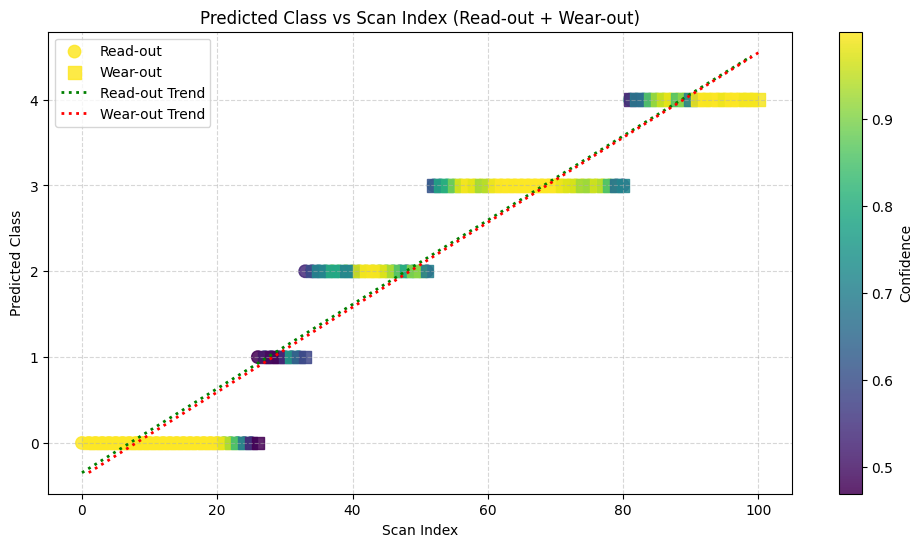

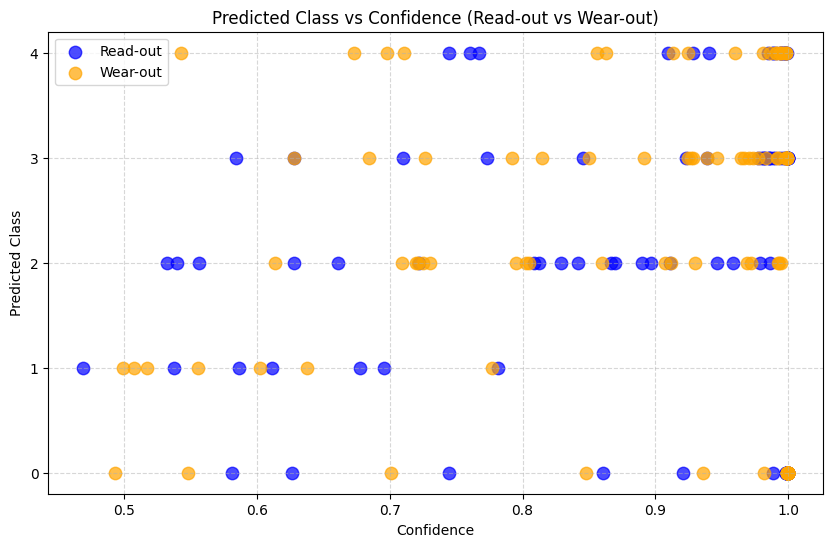

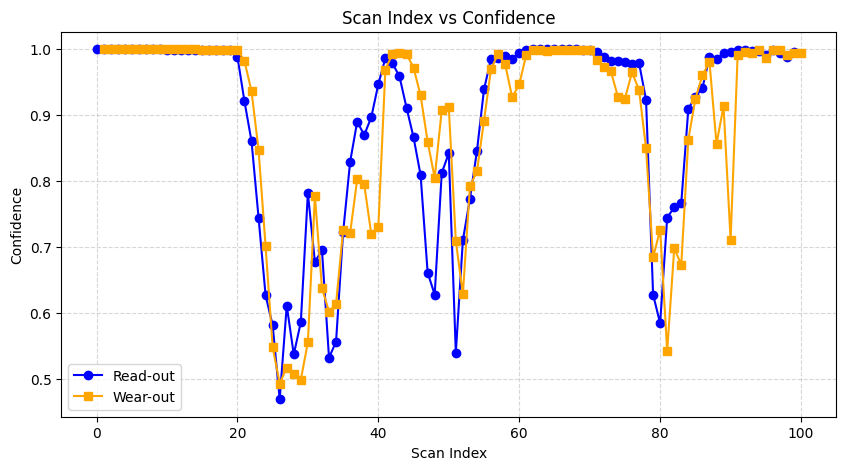

Model loaded from best_hybrid_model_nor94.pth
Predicting quality for 100 files...
Processing file 1/100: exp_data2/read_out/Read_out_0000.ibw
File: Read_out_0000.ibw, Extracted scan_index: 0
Scan Index: 0 Predicted: Class 0 (Excellent (Class 0)) with 1.000 confidence
Processing file 2/100: exp_data2/read_out/Read_out_0001.ibw
File: Read_out_0001.ibw, Extracted scan_index: 1
Scan Index: 1 Predicted: Class 0 (Excellent (Class 0)) with 1.000 confidence
Processing file 3/100: exp_data2/read_out/Read_out_0002.ibw
File: Read_out_0002.ibw, Extracted scan_index: 2
Scan Index: 2 Predicted: Class 0 (Excellent (Class 0)) with 1.000 confidence
Processing file 4/100: exp_data2/read_out/Read_out_0003.ibw
File: Read_out_0003.ibw, Extracted scan_index: 3
Scan Index: 3 Predicted: Class 0 (Excellent (Class 0)) with 1.000 confidence
Processing file 5/100: exp_data2/read_out/Read_out_0004.ibw
File: Read_out_0004.ibw, Extracted scan_index: 4
Scan Index: 4 Predicted: Class 0 (Excellent (Class 0)) with 1.000

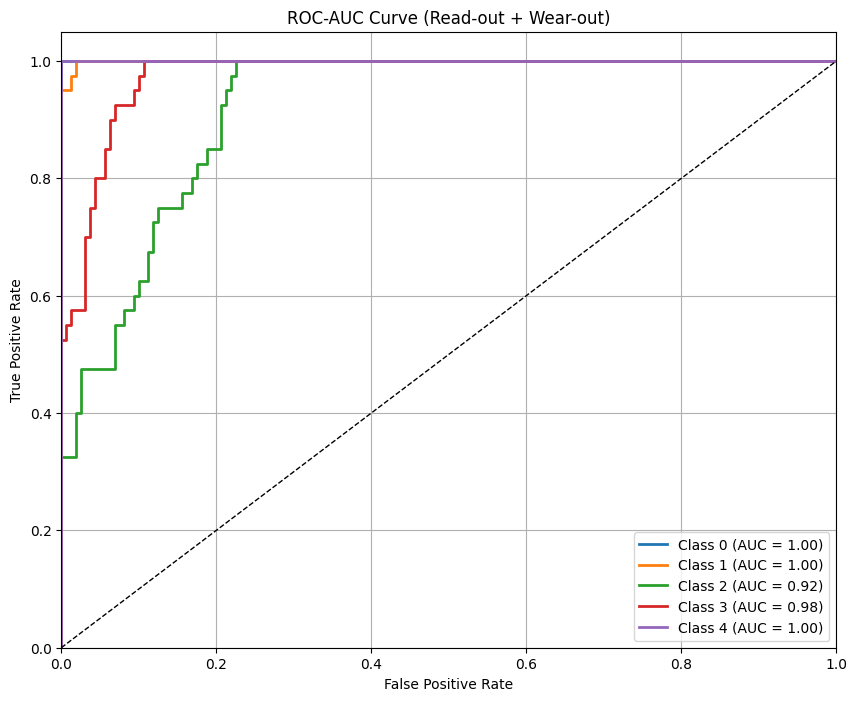


Per-Class AUC Scores:
  Class 0: 1.0000
  Class 1: 0.9992
  Class 2: 0.9209
  Class 3: 0.9764
  Class 4: 1.0000
Model loaded from best_hybrid_model_nor94.pth
Found 100 files in exp_data2/read_out
Found 100 files in exp_data2/wear_out
Predicting quality for 200 files...
Processing file 1/200: exp_data2/read_out/Read_out_0000.ibw
File: Read_out_0000.ibw, Extracted scan_index: 0
Scan Index: 0 Predicted: Class 0 (Excellent (Class 0)) with 1.000 confidence
Processing file 2/200: exp_data2/wear_out/Wear_out_0000.ibw
File: Wear_out_0000.ibw, Extracted scan_index: 0
Scan Index: 0 Predicted: Class 0 (Excellent (Class 0)) with 1.000 confidence
Processing file 3/200: exp_data2/read_out/Read_out_0001.ibw
File: Read_out_0001.ibw, Extracted scan_index: 1
Scan Index: 1 Predicted: Class 0 (Excellent (Class 0)) with 1.000 confidence
Processing file 4/200: exp_data2/wear_out/Wear_out_0001.ibw
File: Wear_out_0001.ibw, Extracted scan_index: 1
Scan Index: 1 Predicted: Class 0 (Excellent (Class 0)) with 1.

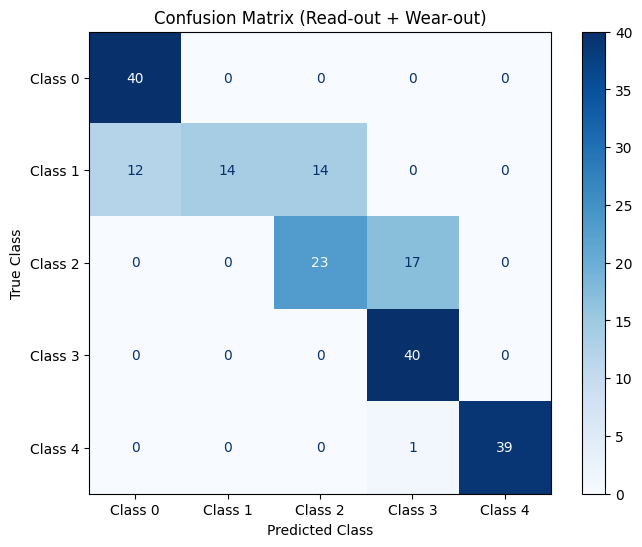

Found 100 IBW files in exp_data2/read_out
Found 100 IBW files in exp_data2/wear_out

Total files loaded: 200
Dataset breakdown:
  _read_out: 100 files
  _wear_out: 100 files
Computing rewards for all images...
Reward normalization: mean=31.6246, std=1.6845
Given reward weights: {'phase_consistency': 10.0, 'amplitude_consistency': 0.25, 'height_consistency': 10.0, 'tip_freshness': 0.0, 'amplitude_std': 5.0, 'height_entropy': 1.0, 'phase_std': 2.0, 'height_skew': 10.0, 'phase_skew': 0.75}


In [16]:
def plot_prediction_versus_index(model_path, base_folder, dataset_names):
    import os
    import numpy as np

    from tools import hb_predict_with_metadata          # Needed for prediction based on augments
    from tools import load_trained_hybrid_model         # For loading a saved model

    import torch

    # This defines the device that we can use for hardware acceleration, as done above
    device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if hasattr(torch, 'has_mps') 
                                and torch.has_mps and torch.mps.is_available() else 'cpu')

    # This loads the trained model from the specified path
    model = load_trained_hybrid_model(model_path, device=device) # Change as needed to observe

    # Define the read_out_folder for prediction with the metadata from training and .ibw files
    read_out_folder = os.path.join(base_folder, dataset_names[0])
    read_out_files = sorted([
        os.path.join(read_out_folder, f)
        for f in os.listdir(read_out_folder)
        if f.lower().endswith(".ibw")
    ])

    # The same process applies to wear_out folders
    wear_out_folder = os.path.join(base_folder, dataset_names[1])
    wear_out_files = sorted([
        os.path.join(wear_out_folder, f)
        for f in os.listdir(wear_out_folder)
        if f.lower().endswith(".ibw")
    ])

    # If you have metadata, instead we use defaults from the experiment
    model_metadata_path = ""

    # Grabs the results from each file, averaged over the 72 augmented images
    results_read = hb_predict_with_metadata(model, read_out_files, model_metadata_path, device)
    results_wear = hb_predict_with_metadata(model, wear_out_files, model_metadata_path, device)

    # Read-out
    scan_indices_read = [r.get('scan_index', r.get('scan_index_used', i + 1)) for i, r in enumerate(results_read)]
    predicted_classes_read = [r['predicted_class'] for r in results_read]
    confidences_read = [r['confidence'] for r in results_read]

    # Wear-out (reset scan index to start from 1)
    scan_indices_wear = [i + 1 for i in range(len(results_wear))]
    predicted_classes_wear = [r['predicted_class'] for r in results_wear]
    confidences_wear = [r['confidence'] for r in results_wear]


    # --- PLOTTING ---
    import matplotlib.pyplot as plt

    # Plot both with confidence as color, wear-out as squares, read-out as circles
    plt.figure(figsize=(12, 6))

    # Read-out: circles, color by confidence
    scatter1 = plt.scatter(
        scan_indices_read, predicted_classes_read, 
        c=confidences_read, cmap='viridis', s=80, alpha=0.85, label='Read-out', marker='o'
    )
    # Wear-out: squares, color by confidence
    scatter2 = plt.scatter(
        scan_indices_wear, predicted_classes_wear, 
        c=confidences_wear, cmap='viridis', s=80, alpha=0.85, label='Wear-out', marker='s'
    )

    # Add trendline for read-out
    z_read = np.polyfit(scan_indices_read, predicted_classes_read, 1)
    p_read = np.poly1d(z_read)
    plt.plot(scan_indices_read, p_read(scan_indices_read), color='green', linewidth=2, linestyle=':', label='Read-out Trend')

    # Add trendline for wear-out
    z_wear = np.polyfit(scan_indices_wear, predicted_classes_wear, 1)
    p_wear = np.poly1d(z_wear)
    plt.plot(scan_indices_wear, p_wear(scan_indices_wear), color='red', linewidth=2, linestyle=':', label='Wear-out Trend')

    # General plot configuration--may require labeling changers
    plt.xlabel('Scan Index')
    plt.ylabel('Predicted Class')
    plt.title(f'Predicted Class vs Scan Index (Read-out + Wear-out)')
    plt.yticks(range(5), ['0', '1', '2', '3', '4'])
    cbar = plt.colorbar(scatter1, label='Confidence', orientation='vertical')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.scatter(confidences_read, predicted_classes_read, c='blue', label='Read-out', alpha=0.7, s=80)
    plt.scatter(confidences_wear, predicted_classes_wear, c='orange', label='Wear-out', alpha=0.7, s=80)
    plt.xlabel('Confidence')
    plt.ylabel('Predicted Class')
    plt.title(f'Predicted Class vs Confidence (Read-out vs Wear-out)')
    plt.yticks(range(5), ['0', '1', '2', '3', '4'])
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()

    # Plot scan index vs. confidence for both read-out and wear-out
    plt.figure(figsize=(10, 5))
    plt.plot(scan_indices_read, confidences_read, marker='o', color='blue', label='Read-out')
    plt.plot(scan_indices_wear, confidences_wear, marker='s', color='orange', label='Wear-out')
    plt.xlabel('Scan Index')
    plt.ylabel('Confidence')
    plt.title('Scan Index vs Confidence')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()

def hb_roc_auc_script(model_path, base_folder, dataset_names):
    import torch.nn.functional as F
    import torch
    from tools import load_trained_hybrid_model, add_true_labels_to_results_using_scan_indices
    from tools import hb_generate_roc_auc_curve
    import os

    metadata_path = "model_training_metadata.pkl"   # Don't need to change
    device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if hasattr(torch, 'has_mps') and torch.has_mps and torch.mps.is_available() else 'cpu')

    # Loads the mode
    model = load_trained_hybrid_model(model_path, device=device)

    # Define the read_out_folder for prediction with the metadata from training and .ibw files
    read_out_folder = os.path.join(base_folder, dataset_names[0])
    read_out_files = sorted([
        os.path.join(read_out_folder, f)
        for f in os.listdir(read_out_folder)
        if f.lower().endswith(".ibw")
    ])

    # The same process applies to wear_out folders
    wear_out_folder = os.path.join(base_folder, dataset_names[1])
    wear_out_files = sorted([
        os.path.join(wear_out_folder, f)
        for f in os.listdir(wear_out_folder)
        if f.lower().endswith(".ibw")
    ])

    read_out_files = sorted([
        os.path.join(read_out_folder, f) for f in os.listdir(read_out_folder)
        if f.lower().endswith(".ibw")
    ])
    wear_out_files = sorted([
        os.path.join(wear_out_folder, f) for f in os.listdir(wear_out_folder)
        if f.lower().endswith(".ibw")
    ])

    from tools import hb_predict_with_metadata, AugmentedTransform


    # # Predict on both datasets
    results_read = hb_predict_with_metadata(model, read_out_files, metadata_path, device)
    results_wear = hb_predict_with_metadata(model, wear_out_files, metadata_path, device)

    # Combine results and generate ROC curve
    all_results = results_read + results_wear
    all_results = add_true_labels_to_results_using_scan_indices(all_results)

    # inspect_results(all_results)
    roc_auc = hb_generate_roc_auc_curve(all_results, num_classes=5, title="ROC-AUC Curve (Read-out + Wear-out)")

    print("\nPer-Class AUC Scores:")
    for cls, score in roc_auc.items():
        print(f"  Class {cls}: {score:.4f}")

if __name__ == "__main__":
    # Define the model path here
    model_path = 'best_hybrid_model_nor94.pth'

    # w/i -series
    reward_weights = {
        'phase_consistency': 10.0,
        'amplitude_consistency': 0.25,
        'height_consistency': 10.0,
        'tip_freshness': 0.00,
        'amplitude_std': 5.0,
        'height_entropy': 1.0,
        'phase_std': 2.0,
        'height_skew': 10.0,
        'phase_skew': 0.75
    }


    # Define the base folder and the subfolders which contain the set of data
    # This *is* configurable for other experiments, but will not be labeled as such
    # Change the above functions for plotting if the experimental procedure changes
    base_folder = 'exp_data2'
    dataset_names = ['read_out', 'wear_out']

    # Usage
    plot_prediction_versus_index(model_path, base_folder, dataset_names)

    # # Configure the file base folder here for predictions
    # base_folder = "exp_data/June 18"
    # dataset_names = ["read_out", "wear_out"]
    # model_path = 'hybrid_model.pth'

    # Run the script (useful in other .py files)
    hb_roc_auc_script(model_path, base_folder, dataset_names)


    # Run the confusion matrix script as well
    from tools import hb_compute_confusion_matrix_from_multiple_folders
    from tools import load_trained_hybrid_model
    import torch

    device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if hasattr(torch, 'has_mps') and torch.has_mps and torch.mps.is_available() else 'cpu')
    model = load_trained_hybrid_model(model_path, device=device)


    hb_compute_confusion_matrix_from_multiple_folders(
        parent_folder=base_folder,
        subfolders=dataset_names,
        model=model,
        num_classes=5,
        title="Confusion Matrix (Read-out + Wear-out)"
    )

    from tools import PCAAnalyzer, run_pca_analysis
    from tools import load_multi_dataset, AugmentedIBWDataset, custom_collate
    import torch
    from torch.utils.data import Dataset, DataLoader

    # Auto configure the device
    device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if hasattr(torch, 'has_mps') and torch.has_mps and torch.mps.is_available() else 'cpu')

    # Configure the base folders here, as needed for dataset creation
    base_folders = ["exp_data2/"]
    dataset_names = ["read_out", "wear_out"]

    # This loads the dataset
    all_files, all_labels, all_scan_indices, dataset_info = load_multi_dataset(
            base_folders, dataset_names)

    # Extract features from the validation dataloader
    dataset = AugmentedIBWDataset(
        all_files, 
        all_labels, 
        all_scan_indices,
        compute_rewards=True,
        use_augmentation=True,
        augmentation_factor=72,  # 9 crops * 4 rotations * 2 flips = 72
        reward_weights=reward_weights
    )

    # Split dataset for training and validation, using an 80/20 train/test split
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

    val_dataloader = DataLoader(val_dataset, batch_size=16, shuffle=False, 
                                collate_fn=custom_collate, num_workers=0)

    # # Initialize the analyzer. You can configure this as needed for both models.
    # analyzer = run_pca_analysis(
    #     hybrid_model_path=model_path,
    #     barlow_model_path='barlow_twins_multiclass_classifier_v1.pth', 
    #     test_dataloader=val_dataloader,
    #     device=device,
    #     max_samples=2000    # Experimental max is more, depends on dataset (not including head)
    # )



Model loaded from best_hybrid_model_w10.pth
0
{'file_path': 'exp_data2/test_0000.ibw', 'predicted_class': 0, 'quality_description': 'Excellent (Class 0)', 'confidence': 0.999975860118866, 'class_probabilities': array([9.9997586e-01, 1.7632165e-05, 6.4257057e-07, 1.9816803e-06,
       3.9188494e-06], dtype=float32), 'predicted_reward_normalized': -1.9903109073638916, 'predicted_reward_original': -1.9903109073638916, 'actual_reward': 1.0352193673084902, 'reward_difference': 3.0255302746723816, 'scan_index_used': 0, 'num_augmentations': 72}


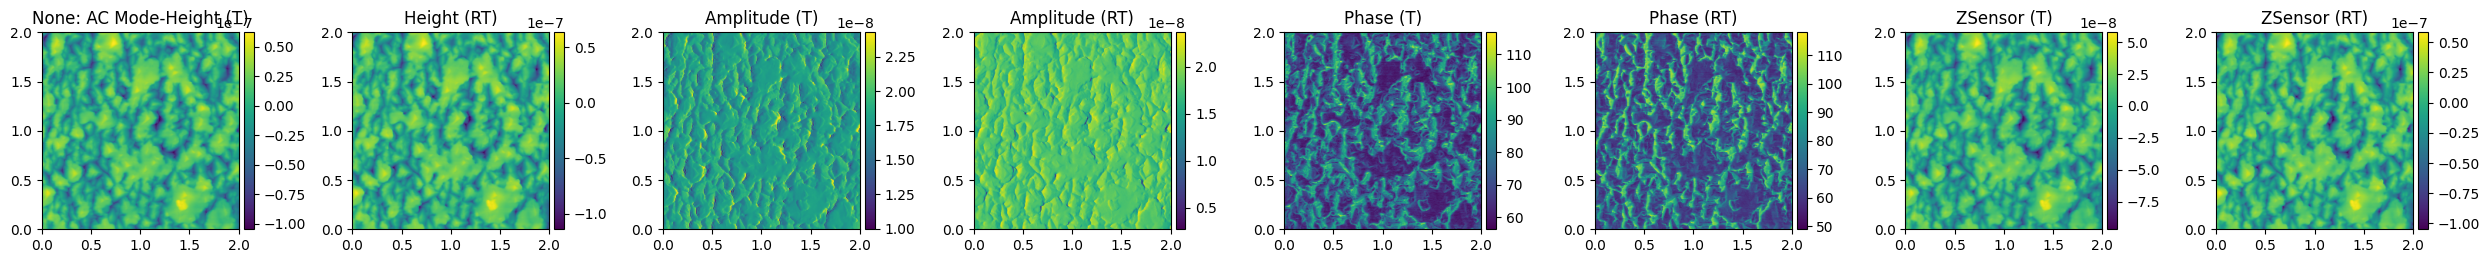

In [30]:
from tools import hb_predict_ibw, load_trained_hybrid_model, extract_scan_index_from_filename
import torchvision.transforms as transforms                         # Image transforms
from tools import AugmentedTransform

from tools import display_ibw

if __name__ == "__main__":
    model_path = 'best_hybrid_model_w10.pth'
    # file_path = 'exp_data2/test_0000.ibw'
    file_path = 'exp_data2/test_0000.ibw'

    display_ibw(file_path)

    # transform = transforms.Compose([
    #         transforms.Resize((224, 224)),
    #         transforms.ToTensor(),
    #         transforms.Normalize(mean=[0.485, 0.456, 0.406],
    #                            std=[0.229, 0.224, 0.225]),
    # ])

    aug_transform = AugmentedTransform(base_size=256, crop_size=86, normalize=True)

    device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if hasattr(torch, 'has_mps') and torch.has_mps and torch.mps.is_available() else 'cpu')
    model = load_trained_hybrid_model(model_path, device=device)

    scan_index = extract_scan_index_from_filename(file_path)
    print(scan_index)

    results = hb_predict_ibw(model=model, ibw_file_path=file_path, transform=aug_transform, device=device, scan_index=scan_index )
    print(results)

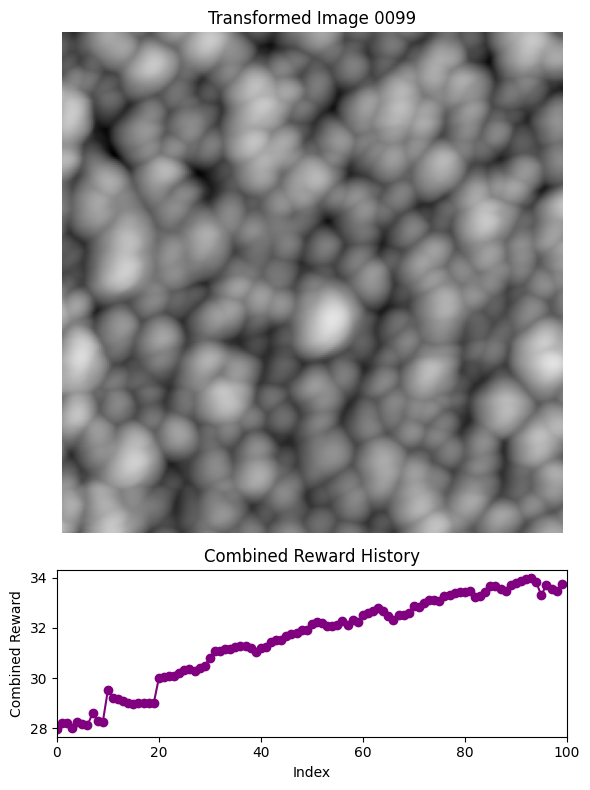

In [11]:
import matplotlib.pyplot as plt
import torch
from IPython.display import clear_output
from tools import load_ibw, AugmentedTransform, compute_reward_with_top_features
from PIL import Image
import numpy as np

reward_weights = {
        'phase_consistency': 10.0,
        'amplitude_consistency': 0.25,
        'height_consistency': 10.0,
        'tip_freshness': 0.00,
        'amplitude_std': 5.0,
        'height_entropy': 1.0,
        'phase_std': 2.0,
        'height_skew': 10.0,
        'phase_skew': 0.75
    }  # Leave empty, you will fill as needed

rewards_history = []

for idx in range(100):
    ibw_path = f'exp_data2/read_out/read_out_{idx:04d}.ibw'
    ibw_obj = load_ibw(ibw_path)
    height_img = ibw_obj.z

    # Normalize and convert to PIL RGB
    h_min = np.min(height_img)
    h_max = np.max(height_img)
    norm_img = 255 * (height_img - h_min) / (h_max - h_min + 1e-8)
    norm_img = norm_img.astype(np.uint8)
    pil_img = Image.fromarray(norm_img).convert("RGB")

    # Transform
    transform = AugmentedTransform(base_size=224, crop_size=256, normalize=True)
    tensor = transform._to_tensor_and_normalize(pil_img)

    # Prepare for display
    if transform.normalize_transform:
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        tensor_disp = tensor * std + mean
    else:
        tensor_disp = tensor

    tensor_disp = torch.clamp(tensor_disp, 0, 1)
    img_disp = tensor_disp.permute(1, 2, 0).cpu().numpy()

    # --- Compute reward ---
    scan_index = idx  # or extract from filename if needed
    combined_reward, rewards_dict = compute_reward_with_top_features(
        ibw_obj, scan_index=scan_index, weights=reward_weights, return_all=True
    )
   
    # After computing combined_reward
    # reversed_reward = -combined_reward  # Simple negation (if you want high to become low)

    # Or, if you want to keep rewards positive and just flip the order:
   

    rewards_history.append(combined_reward)

    # --- Display both image and reward history ---
    clear_output(wait=True)
    fig, axs = plt.subplots(2, 1, figsize=(6, 8), gridspec_kw={'height_ratios': [3, 1]})

    # Show image
    axs[0].imshow(img_disp)
    axs[0].axis('off')
    axs[0].set_title(f"Transformed Image {idx:04d}")

    # Show reward history as a line plot
    axs[1].plot(rewards_history, marker='o', color='purple')
    axs[1].set_xlim(0, 100)
      # Adjust if your reward can be outside [0,1]
    axs[1].set_xlabel('Index')
    axs[1].set_ylabel('Combined Reward')
    axs[1].set_title('Combined Reward History')

    plt.tight_layout()
    plt.show()